## Expoloratory Analysis

### Imports: 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import time 
import requests
import dotenv

from tqdm import tqdm
from dotenv import load_dotenv
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: str | ForwardRef('os.PathLike[str]') | None = None, stream: IO[str] | None = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: str | None = 'utf-8') -> bool>

### read the complete.csv file 
- note: a few of the rows have extra columns, initially this was causing an error 
- Found a workaround with use usecols=range(0, 11)

In [7]:
df = pd.read_csv("complete.csv", usecols=range(0, 11))


C:\Users\wslid\AppData\Local\Temp\ipykernel_14864\1562196856.py:1: DtypeWarning: Columns (0: duration (seconds)) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("complete.csv", usecols=range(0, 11))


### Initial Observations 

- datetime is a string type, will convert to datetime type
- state has a siginificant number of null values (data includes non us locations)
- country has null values .. limit analysis to US only sightings? 
- durration (seconds) is an object - should be float
- durration (hours / min) is a string .. could be divided into two int columns 
- date posted is a string - could become datetime? 
- latitude is a string - needs to be a float type (like longitude)

- add columns for weather data at the time of sightings 

- data scews heavily toward US sightings ( perhaps only look at US sightings in most cases )

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88875 entries, 0 to 88874
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              88875 non-null  str    
 1   city                  88679 non-null  str    
 2   state                 81356 non-null  str    
 3   country               76314 non-null  str    
 4   shape                 85757 non-null  str    
 5   duration (seconds)    88873 non-null  object 
 6   duration (hours/min)  85772 non-null  str    
 7   comments              88749 non-null  str    
 8   date posted           88875 non-null  str    
 9   latitude              88875 non-null  str    
 10  longitude             88875 non-null  float64
dtypes: float64(1), object(1), str(9)
memory usage: 7.5+ MB


In [6]:
df.head(10)

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611
5,10/10/1961 19:00,bristol,tn,us,sphere,300,5 minutes,My father is now 89 my brother 52 the girl wit...,4/27/2007,36.5950000,-82.188889
6,10/10/1965 21:00,penarth (uk/wales),NaN,gb,circle,180,about 3 mins,penarth uk circle 3mins stayed 30ft above m...,2/14/2006,51.434722,-3.180000
7,10/10/1965 23:45,norwalk,ct,us,disk,1200,20 minutes,A bright orange color changing to reddish colo...,10/2/1999,41.1175000,-73.408333
8,10/10/1966 20:00,pell city,al,us,disk,180,3 minutes,Strobe Lighted disk shape object observed clos...,3/19/2009,33.5861111,-86.286111
9,10/10/1966 21:00,live oak,fl,us,disk,120,several minutes,Saucer zaps energy from powerline as my pregna...,5/11/2005,30.2947222,-82.984167


In [13]:
df.describe()

,datetime,latitude,longitude,rounded_lat,year
count,87613,88678.000000,88875.000000,69650.000000,87613.000000
mean,2004-04-04 08:00:34.616096,37.453081,-84.834334,38.337042,2003.733384
min,1906-11-11 00:00:00,-82.862752,-176.658056,25.000000,1906.000000
25%,2001-06-25 21:00:00,34.035000,-112.046944,34.000000,2001.000000
50%,2006-10-03 23:45:00,39.233333,-87.650000,39.000000,2006.000000
75%,2011-05-22 19:31:00,42.717836,-77.615833,42.000000,2011.000000
max,2014-05-08 18:45:00,72.700000,178.441900,49.000000,2014.000000
std,NaN,11.572496,41.567822,5.244670,10.487175


### Core Questions : 
- When and Where are You Most Likely to See a UFO / UAP? 
    - Are there hotspots / concentrations of sightings? 
    - Are there ideal conditions for viewing?
    - Do the frequency of sightings correlate with an time, place or conditions? 
- Are there any trends over time in frquency and type / shape? 

### Initial Followup Questions: 

- Where do most sightings occur? 
    - Latitude of US lower 48 sightings (histogram)
    - Longitude of US lower 48 sightings (histogram)

- Are there any trends in types of sightings? 
    - Total number of sightings each year
    - Types / Shapes of sightings ( as % of sightings that year )
    - Kentucky sightings 

- When to most sightings occur? 
    - Time ( 24 Hours )
    - Time of Year ( Month and Season )

- Weather and Sightings
    - * Use Weather API to create a new CSV with additional columns for conditions, temperature, ect ..
        - Use Location and Time data to call Weather API for each Row
        - Write to new CSV  
    - Temperature at the time of sightings
    - Weather Conditions at the time of sightings

- Advanced Location
    - names of places - would a place named "mystery", "erie" or "starlight" have more sightings?
    - use actual place names in Data Set

    - US Map showing states and number of sightings ( per capita )
        - Use color scale ( darker = more sightings )
 


### Latitude of US Lower 48 Sightings :
    - Change Latitude to Int / Numeric Type
    - Filter Latitude for Lower 48 range (24 - 50)
    - Filter Country for "us"
    - Line for Average (mean) latitude
    - create a Histogram with bins for each latitude 

### Observations :
    - Average latitude line crosses North Central Kentucky 
    - 2 Clusters Emerge :
        - Cluster 1: Centered at around 34 North
        - Cluster 2: Centered at around 41 North 

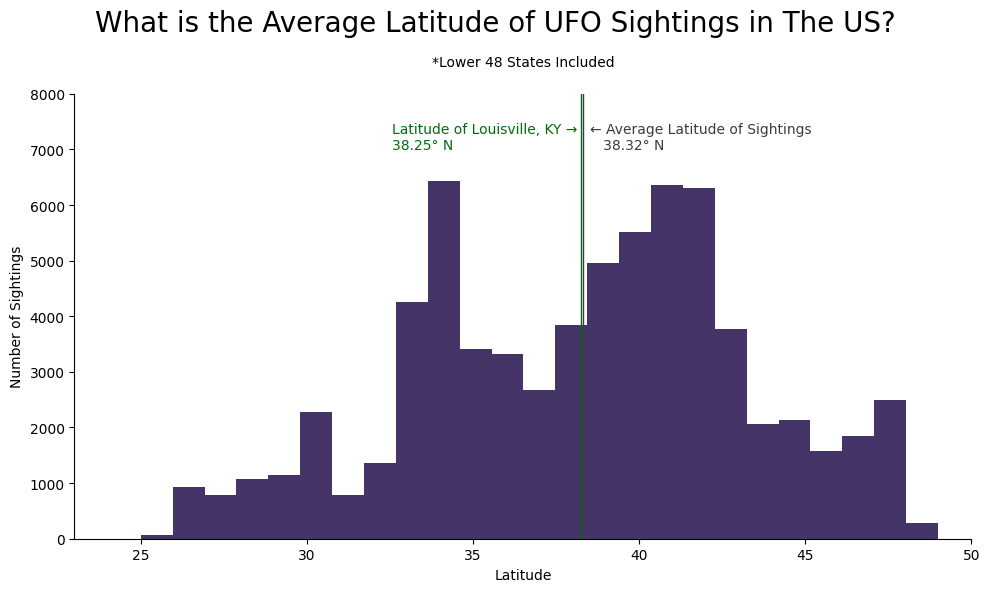

In [9]:
# latitude cleaning 
df["latitude"] = pd.to_numeric(
    df["latitude"].astype(str).str.replace(r".*/.*", "", regex=True),
    errors="coerce"
)

# rounded_lat for lower 48 
df["rounded_lat"] = df["latitude"].where(
    (df["country"].str.lower() == "us") & 
    (df["latitude"].between(24, 50))
).round(0)

mean_latitude = df["latitude"].where(
    (df["country"].str.lower() == "us") & 
    (df["latitude"].between(24, 50))
).mean().round(2)

louisville_latitude = 38.25

plt.figure(figsize=(10,6))

# Histogram with Only non-NaN US Values
plt.hist(df['rounded_lat'].dropna(), 
         bins=25,                    
         color="#170141", 
         alpha=0.8)

plt.xlabel("Latitude")
plt.ylabel("Number of Sightings")
plt.suptitle("What is the Average Latitude of UFO Sightings in The US?", fontsize=20)
plt.title("*Lower 48 States Included", fontsize=10, pad=20)

ax = plt.gca()
ax.axvline(mean_latitude, linewidth=1, color="#3a3b45")
ax.text(mean_latitude + 0.2, 7000,
        f"← Average Latitude of Sightings\n   {mean_latitude}° N",
        color="#3a3b45")

ax.axvline(louisville_latitude, linewidth=1, color="#006c0e")
ax.text(louisville_latitude - 5.7, 7000,
        f"Latitude of Louisville, KY →\n{louisville_latitude}° N",
        color="#006c0e")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(23, 50)
plt.ylim(0, 8000)

plt.tight_layout()
plt.show()

### Increase in UFO sightings over time
    - Line Chart shows a dramatic increase in UFO reports beginning in the late 1990s  

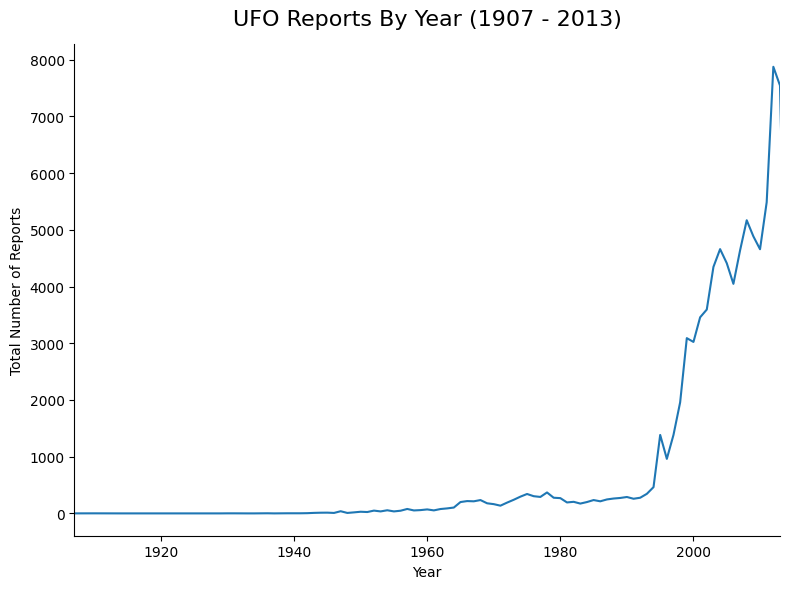

In [18]:
df['datetime'] = pd.to_datetime(df['datetime'].astype(str), errors="coerce")
df['year'] = df['datetime'].dt.year

yearly_totals = df.groupby(['year']).size()

plt.figure(figsize=(8, 6))

plt.plot(yearly_totals.index, yearly_totals)

# data set begins in Nov 1906 and ends in May 2014
# limit x axis to include only complete years (1907 - 2013)
plt.xlim(1907 , 2013)

plt.title("UFO Reports By Year (1907 - 2013)", fontsize=16, pad=14)
plt.xlabel("Year")
plt.ylabel("Total Number of Reports")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

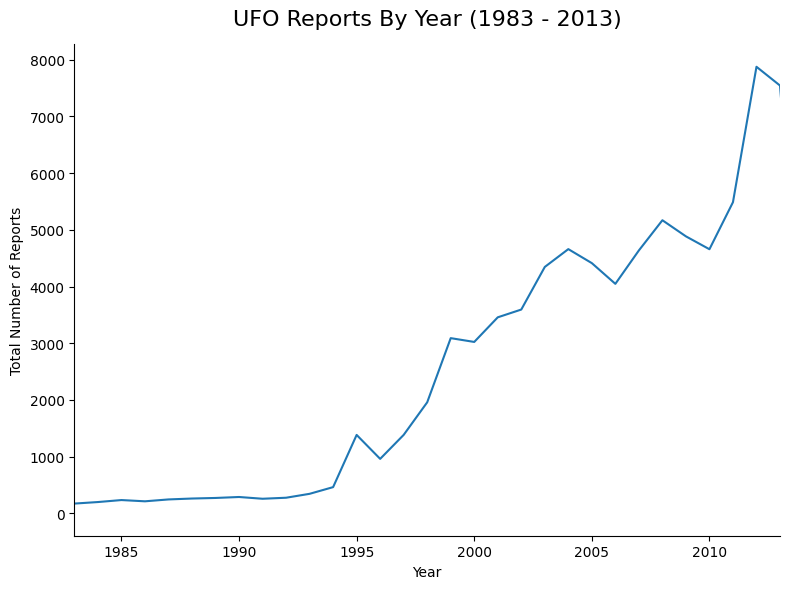

In [22]:
df['datetime'] = pd.to_datetime(df['datetime'].astype(str), errors="coerce")
df['year'] = df['datetime'].dt.year

yearly_totals = df.groupby(['year']).size()

plt.figure(figsize=(8, 6))

plt.plot(yearly_totals.index, yearly_totals)

# data set begins in Nov 1906 and ends in May 2014
# limit x axis to include only complete years (1907 - 2013)
plt.xlim(1983 , 2013)

plt.title("UFO Reports By Year (1983 - 2013)", fontsize=16, pad=14)
plt.xlabel("Year")
plt.ylabel("Total Number of Reports")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Find Shapes and Types of Sightings (total reports for each "shape") + When They Were Seen ( Average Datetime to begin)
- These could be grouped / consolidated ( example: "light" and "flash" are similar )

In [ ]:
# Group by shape
shapes = df.groupby('shape')

# Total sightings per shape (sorted descending)
shape_totals = shapes.size().sort_values(ascending=False)

# Average sighting datetime per shape
shapes_avg_year = shapes['datetime'].mean()

# Combine them 
shapes_avg_year_totals_df = pd.concat(
    [shapes_avg_year, shape_totals], 
    axis=1
)

# Rename columns
shapes_avg_year_totals_df.columns = ['avg_datetime', 'total_sightings']

# Sort by total sightings
shapes_avg_year_totals_df = shapes_avg_year_totals_df.sort_values('total_sightings', ascending=False)

print(shapes_avg_year_totals_df)

                        avg_datetime  total_sightings
shape                                                
light     2005-09-14 01:32:04.464235            17872
triangle  2004-05-19 00:22:41.853171             8489
circle    2005-03-18 07:35:28.558072             8453
fireball  2007-04-09 05:15:29.617452             6562
unknown   2004-07-29 17:23:45.595754             6319
other     2003-07-30 06:21:39.023361             6247
disk      1997-06-04 06:38:06.419459             6005
sphere    2004-09-26 06:28:45.310635             5755
oval      2003-05-14 17:23:23.249630             4119
formation 2005-08-11 19:15:21.934015             2657
cigar     2000-04-05 04:03:21.197278             2241
changing  2005-08-24 13:52:04.938505             2140
flash     2006-08-25 14:44:05.848670             1472
rectangle 2003-10-21 19:56:02.136752             1418
cylinder  2003-08-20 08:24:27.308823             1382
diamond   2004-11-16 10:33:32.664092             1308
chevron   2003-07-22 04:21:4